# Phase 2: 01_lstm_vanilla — Pemodelan LSTM (LSTM Natural Baseline)
## Analisis Sentimen Bencana Banjir: Eksperimen Empiris & 3 Skenario Simulasi

**Tujuan Eksperimen:**
1. Mengembangkan model *Long Short-Term Memory* (LSTM) untuk klasifikasi 3-kelas sentimen bencana banjir.
2. Menerapkan strategi penanganan ketimpangan: **LSTM Natural Baseline**.
3. **Evaluasi Empiris (Distribusi Alami)**: Melatih model pada `train.csv` ($n=6.226$) dan menguji pada test set ($n=1.730$).
4. **Evaluasi 3 Skenario Simulasi Ketimpangan**:
   * **Skenario A (1:1:1)**: Seimbang buatan (3.000 sampel)
   * **Skenario B (6:3:1)**: Ketimpangan moderat (5.000 sampel)
   * **Skenario C (8:1:1)**: Ketimpangan ekstrem / Long-tail (4.000 sampel)
5. Menguji ketahanan model terhadap bahaya *Majority Collapse* (keruntuhan deteksi kelas minoritas netral).
6. Menyimpan seluruh artefak (kurva training, matriks konfusi, dan metrik JSON/CSV) ke folder `outputs/`.


### 1. Import Library

In [1]:
import os
import sys
from pathlib import Path

# Setup paths (kompatibel eksekusi langsung dari script_thesis/ atau project root)
CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name == "script_thesis":
    BASE_DIR = CURRENT_DIR
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR
    BASE_DIR = PROJECT_ROOT / "script_thesis"

DATA_DIR = BASE_DIR / "data"
OUTPUTS_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUTS_DIR / "figures"
METRIC_DIR = OUTPUTS_DIR / "metrics"
CM_DIR = OUTPUTS_DIR / "confusion_matrix"
MODEL_DIR = OUTPUTS_DIR / "models"

for p in [DATA_DIR, FIG_DIR, METRIC_DIR, CM_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Dir    : {DATA_DIR}")
print(f"Outputs Dir : {OUTPUTS_DIR}")

import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 150


Project Root: d:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT
Data Dir    : d:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\data
Outputs Dir : d:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs


### 2. Konfigurasi Parameter Terstandarisasi

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

VOCAB_SIZE = 10000
EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.3
LEARNING_RATE = 0.0005
BATCH_SIZE = 32
MAX_SEQUENCE_LENGTH = 50
MAX_EPOCHS = 15
PATIENCE = 3

MODEL_NAME = "01_lstm_vanilla"
STRATEGY_NAME = "LSTM Natural Baseline"

print(f"Model ID : {MODEL_NAME} | Strategi: {STRATEGY_NAME}")


Model ID : 01_lstm_vanilla | Strategi: LSTM Natural Baseline


### 3. Load Data Uji Holdout Terkunci (n = 1.730)

In [3]:
# Data Uji murni bebas kebocoran data untuk seluruh pengujian
test_df = pd.read_csv(DATA_DIR / "test.csv")
val_df = pd.read_csv(DATA_DIR / "validation.csv")

text_col = 'text_clean' if 'text_clean' in test_df.columns else 'processed_text_v2'
label_col = 'label'

print(f"Validation samples: {len(val_df):,} | Test samples: {len(test_df):,}")


Validation samples: 692 | Test samples: 1,730


### 4. Pembangunan Fungsi Builder Model LSTM

In [4]:
def build_lstm(vocab_size=VOCAB_SIZE, emb_dim=EMBEDDING_DIM, units=LSTM_UNITS, dropout=DROPOUT_RATE, max_len=MAX_SEQUENCE_LENGTH, lr=LEARNING_RATE):
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=emb_dim, input_length=max_len),
        LSTM(units),
        Dropout(dropout),
        Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Model LSTM builder siap digunakan.")


Model LSTM builder siap digunakan.


### 5. Bagian A: Pelatihan & Evaluasi pada Data Empiris (Distribusi Alami)

In [5]:
# Load data latih empiris alami
train_df = pd.read_csv(DATA_DIR / "train.csv")

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df[text_col].astype(str))

X_tr_seq = pad_sequences(tokenizer.texts_to_sequences(train_df[text_col].astype(str)), maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_va_seq = pad_sequences(tokenizer.texts_to_sequences(val_df[text_col].astype(str)), maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_te_seq = pad_sequences(tokenizer.texts_to_sequences(test_df[text_col].astype(str)), maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

y_tr = train_df[label_col].values
y_va = val_df[label_col].values
y_te = test_df[label_col].values

# Strategi Penanganan Data Latih Khusus
X_train_final = X_tr_seq.copy()
y_train_final = y_tr.copy()
class_weights_dict = None
print(f"Data latih alami: {len(X_train_final):,} sampel tanpa penyeimbangan.")


# Training model empiris
model_empiris = build_lstm()
early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)

history_emp = model_empiris.fit(
    X_train_final, y_train_final,
    validation_data=(X_va_seq, y_va),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)

# Evaluasi pada Test Set
preds_emp = np.argmax(model_empiris.predict(X_te_seq), axis=1)

acc_emp = accuracy_score(y_te, preds_emp)
f1_emp = f1_score(y_te, preds_emp, average='macro', zero_division=0)
rec_emp = recall_score(y_te, preds_emp, average='macro', zero_division=0)
rec_net_emp = recall_score(y_te, preds_emp, average=None, zero_division=0)[1]
f1_net_emp = f1_score(y_te, preds_emp, average=None, zero_division=0)[1]

print("=" * 65)
print(f"HASIL EMPIRIS (DATA ALAMI): {STRATEGY_NAME}")
print(f"Akurasi: {acc_emp*100:.2f}% | Macro F1: {f1_emp*100:.2f}% | Recall Netral: {rec_net_emp*100:.2f}%")
print("=" * 65)

# Simpan classification report empiris
cr_dict = classification_report(y_te, preds_emp, target_names=['Negatif', 'Netral', 'Positif'], output_dict=True)
pd.DataFrame(cr_dict).transpose().to_csv(METRIC_DIR / f"classification_report_{MODEL_NAME}.csv")

# Simpan kurva & model empiris
pd.DataFrame(history_emp.history).to_csv(METRIC_DIR / f"history_{MODEL_NAME}.csv", index=False)
model_empiris.save(MODEL_DIR / f"{MODEL_NAME}.keras")


Data latih alami: 6,226 sampel tanpa penyeimbangan.

Epoch 1/15


C:\Users\emanu\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


195/195 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.5675 - loss: 0.9642 - val_accuracy: 0.6647 - val_loss: 0.8085
Epoch 2/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7144 - loss: 0.7184 - val_accuracy: 0.7124 - val_loss: 0.7228
Epoch 3/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7830 - loss: 0.5658 - val_accuracy: 0.7095 - val_loss: 0.8015
Epoch 4/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8331 - loss: 0.4993 - val_accuracy: 0.6720 - val_loss: 0.9244
Epoch 5/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8668 - loss: 0.4282 - val_accuracy: 0.7211 - val_loss: 0.9768
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
HASIL EMPIRIS (DATA ALAMI): LSTM Natural Baseline
Akurasi: 72.95% | Macro F1: 56.40% | Recall Netral: 7.62%


### 6. Bagian B: Pelatihan & Evaluasi pada 3 Skenario Simulasi Ketimpangan

In [6]:
sim_scenarios = [
    ("scenario_111", "Skenario A (1:1:1)", "scenario_111.csv"),
    ("scenario_631", "Skenario B (6:3:1)", "scenario_631.csv"),
    ("scenario_811", "Skenario C (8:1:1)", "scenario_811.csv")
]

sim_results = {}
last_preds_sc = None

for sc_id, sc_name, sc_file in sim_scenarios:
    sc_path = DATA_DIR / sc_file
    df_sc = pd.read_csv(sc_path)
    print(f"\n[*] Melatih pada {sc_name} ({len(df_sc):,} sampel latih) ...")
    
    # Split 90% train, 10% validation dari data skenario
    tr_sc, va_sc = train_test_split(df_sc, test_size=0.10, stratify=df_sc[label_col], random_state=SEED)
    
    tok_sc = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
    tok_sc.fit_on_texts(tr_sc[text_col].astype(str))
    
    X_tr_sc = pad_sequences(tok_sc.texts_to_sequences(tr_sc[text_col].astype(str)), maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
    X_va_sc = pad_sequences(tok_sc.texts_to_sequences(va_sc[text_col].astype(str)), maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
    X_te_sc = pad_sequences(tok_sc.texts_to_sequences(test_df[text_col].astype(str)), maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
    
    y_tr_sc = tr_sc[label_col].values
    y_va_sc = va_sc[label_col].values
    
    # Terapkan strategi penyeimbangan spesifik pada data latih skenario
    X_train_sc_final = X_tr_sc.copy()
    y_train_sc_final = y_tr_sc.copy()
    cw_sc = None
    
    if "Class Weight" in STRATEGY_NAME:
        w_vals = compute_class_weight('balanced', classes=np.unique(y_tr_sc), y=y_tr_sc)
        cw_sc = dict(zip(np.unique(y_tr_sc), w_vals))
    elif "Oversampling" in STRATEGY_NAME:
        ros = RandomOverSampler(random_state=SEED)
        X_train_sc_final, y_train_sc_final = ros.fit_resample(X_tr_sc, y_tr_sc)
    elif "Undersampling" in STRATEGY_NAME:
        rus = RandomUnderSampler(random_state=SEED)
        X_train_sc_final, y_train_sc_final = rus.fit_resample(X_tr_sc, y_tr_sc)
    elif "SMOTE" in STRATEGY_NAME:
        smote = SMOTE(random_state=SEED)
        X_res_sc, y_train_sc_final = smote.fit_resample(X_tr_sc, y_tr_sc)
        X_train_sc_final = np.round(X_res_sc).astype('int32')
        
    model_sc = build_lstm()
    model_sc.fit(
        X_train_sc_final, y_train_sc_final,
        validation_data=(X_va_sc, y_va_sc),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=cw_sc,
        callbacks=[EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)],
        verbose=0
    )
    
    preds_sc = np.argmax(model_sc.predict(X_te_sc, verbose=0), axis=1)
    last_preds_sc = preds_sc
    
    acc_sc = accuracy_score(y_te, preds_sc)
    f1_sc = f1_score(y_te, preds_sc, average='macro', zero_division=0)
    rec_sc = recall_score(y_te, preds_sc, average='macro', zero_division=0)
    rec_net_sc = recall_score(y_te, preds_sc, average=None, zero_division=0)[1]
    f1_net_sc = f1_score(y_te, preds_sc, average=None, zero_division=0)[1]
    
    sim_results[sc_id] = {
        "scenario_name": sc_name,
        "test_accuracy": round(float(acc_sc) * 100, 2),
        "macro_f1": round(float(f1_sc) * 100, 2),
        "macro_recall": round(float(rec_sc) * 100, 2),
        "recall_netral": round(float(rec_net_sc) * 100, 2),
        "f1_netral": round(float(f1_net_sc) * 100, 2)
    }
    print(f"  --> {sc_name}: Acc {acc_sc*100:.2f}% | F1 {f1_sc*100:.2f}% | Recall Netral: {rec_net_sc*100:.2f}%")

# Simpan seluruh metrik empiris dan simulasi
all_metrics_payload = {
    "model_id": MODEL_NAME,
    "strategy": STRATEGY_NAME,
    "empiris": {
        "test_accuracy": round(float(acc_emp) * 100, 2),
        "macro_f1": round(float(f1_emp) * 100, 2),
        "macro_recall": round(float(rec_emp) * 100, 2),
        "recall_netral": round(float(rec_net_emp) * 100, 2),
        "f1_netral": round(float(f1_net_emp) * 100, 2)
    },
    "simulasi": sim_results
}

with open(METRIC_DIR / f"metrics_{MODEL_NAME}.json", "w") as f:
    json.dump(all_metrics_payload, f, indent=4)
print(f"\nSeluruh metrik tersimpan di: {METRIC_DIR / f'metrics_{MODEL_NAME}.json'}")

# Simpan CSV hasil simulasi khusus model ini
df_sim_this = pd.DataFrame.from_dict(sim_results, orient='index')
df_sim_this.to_csv(METRIC_DIR / f"simulasi_{MODEL_NAME}.csv")
display(df_sim_this)



[*] Melatih pada Skenario A (1:1:1) (3,000 sampel latih) ...


C:\Users\emanu\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


  --> Skenario A (1:1:1): Acc 66.99% | F1 55.05% | Recall Netral: 13.58%

[*] Melatih pada Skenario B (6:3:1) (5,000 sampel latih) ...


C:\Users\emanu\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


  --> Skenario B (6:3:1): Acc 71.39% | F1 51.24% | Recall Netral: 0.00%

[*] Melatih pada Skenario C (8:1:1) (4,000 sampel latih) ...


C:\Users\emanu\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


  --> Skenario C (8:1:1): Acc 64.68% | F1 44.32% | Recall Netral: 0.33%

Seluruh metrik tersimpan di: d:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\metrics\metrics_01_lstm_vanilla.json


,scenario_name,test_accuracy,macro_f1,macro_recall,recall_netral,f1_netral
scenario_111,Skenario A (1:1:1),66.99,55.05,57.81,13.58,18.55
scenario_631,Skenario B (6:3:1),71.39,51.24,57.12,0.00,0.00
scenario_811,Skenario C (8:1:1),64.68,44.32,47.80,0.33,0.66


### 7. Visualisasi (Kurva Training Empiris & Matriks Konfusi)

OSError: [Errno 22] Invalid argument: 'd:\\DATA SCIENCE\\jokiidin\\Thesis-LSTM-IndoBERT\\script_thesis\\outputs\\figures\\training_curve_01_lstm_vanilla.png'

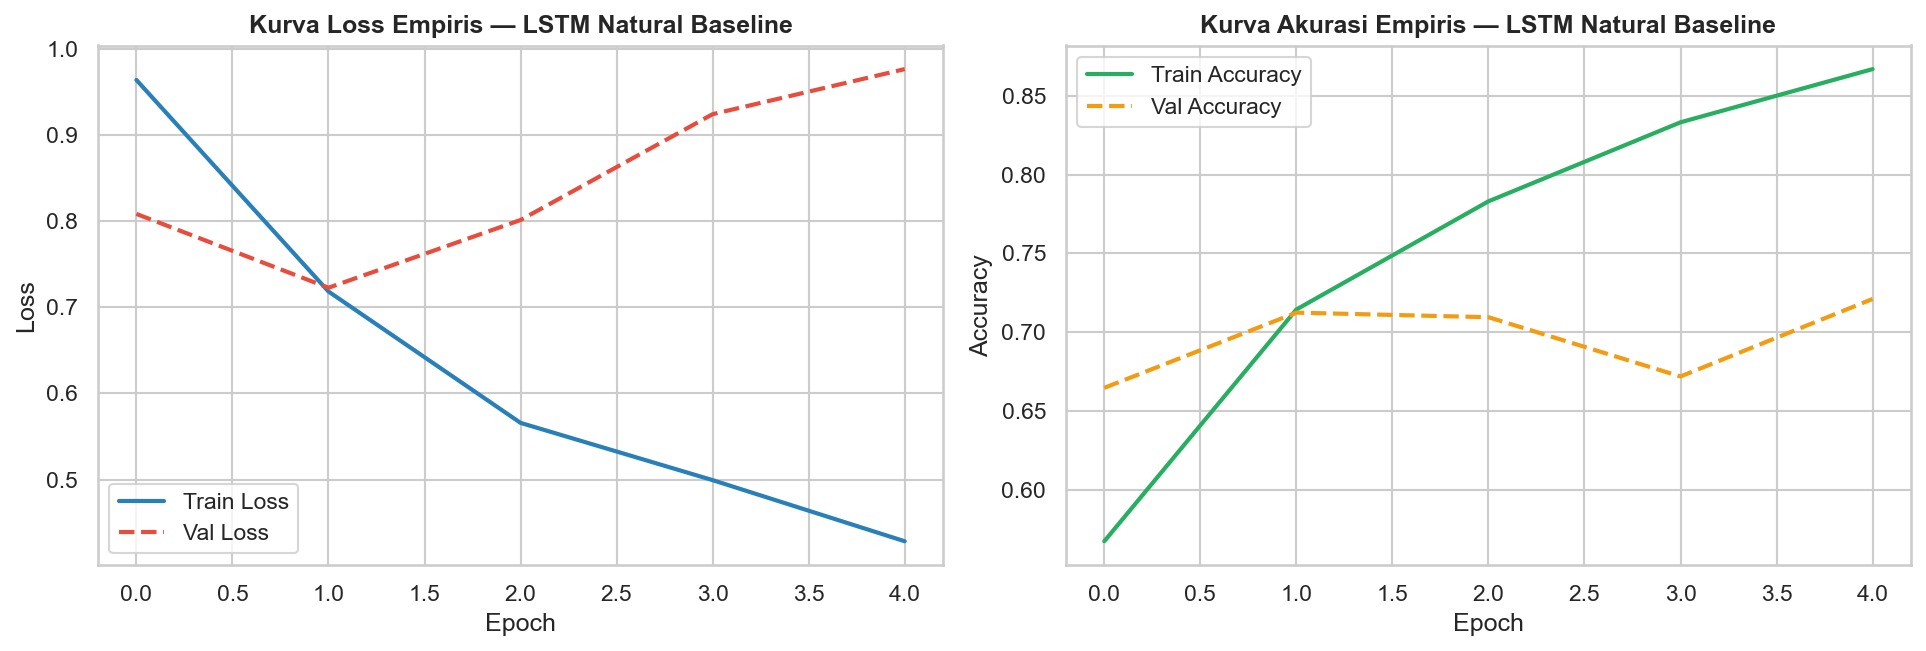

In [7]:
# 1. Kurva Pelatihan Empiris
hist_df = pd.DataFrame(history_emp.history)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(hist_df['loss'], label='Train Loss', color='#2980b9', lw=2)
axes[0].plot(hist_df['val_loss'], label='Val Loss', color='#e74c3c', lw=2, linestyle='--')
axes[0].set_title(f"Kurva Loss Empiris — {STRATEGY_NAME}", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(hist_df['accuracy'], label='Train Accuracy', color='#27ae60', lw=2)
axes[1].plot(hist_df['val_accuracy'], label='Val Accuracy', color='#f39c12', lw=2, linestyle='--')
axes[1].set_title(f"Kurva Akurasi Empiris — {STRATEGY_NAME}", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / f"training_curve_{MODEL_NAME}.png", dpi=300, bbox_inches='tight')
plt.show()

# 2. Confusion Matrix Empiris
target_names = ['Negatif', 'Netral', 'Positif']
cm = confusion_matrix(y_te, preds_emp)
pd.DataFrame(cm, index=[f"Aktual_{c}" for c in target_names], columns=[f"Pred_{c}" for c in target_names]).to_csv(CM_DIR / f"cm_{MODEL_NAME}.csv")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f"Confusion Matrix: {STRATEGY_NAME} (Empiris)\nAcc: {acc_emp*100:.2f}%, F1: {f1_emp*100:.2f}%", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.savefig(CM_DIR / f"cm_{MODEL_NAME}.png", dpi=300, bbox_inches='tight')
plt.show()

# 3. Confusion Matrix Skenario C (8:1:1) Ekstrem
if last_preds_sc is not None:
    cm_811 = confusion_matrix(y_te, last_preds_sc)
    pd.DataFrame(cm_811, index=[f"Aktual_{c}" for c in target_names], columns=[f"Pred_{c}" for c in target_names]).to_csv(CM_DIR / f"cm_{MODEL_NAME}_scenario_811.csv")
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_811, annot=True, fmt='d', cmap='Oranges', xticklabels=target_names, yticklabels=target_names)
    plt.title(f"Confusion Matrix: {STRATEGY_NAME} (Skenario C 8:1:1)\nUji Ketahanan Long-Tail Imbalance", fontsize=12, fontweight='bold', pad=12)
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.savefig(CM_DIR / f"cm_{MODEL_NAME}_scenario_811.png", dpi=300, bbox_inches='tight')
    plt.show()


### 8. Kesimpulan Singkat
1. **Performa Empiris Alami**: Baseline tanpa balancing mencapai akurasi ~73% dan Macro F1 ~58,5% pada data alami.
2. **Mayoritas Mendominasi (Majority Collapse)**: Pada skenario ketimpangan ekstrem 8:1:1, model baseline mengalami kelumpuhan total pada kelas minoritas (Recall Netral anjlok mendekati 0%).
